# 09 · Convolutional neural network: `src/neural_networks/_cnn.py`

Tests for `CNNClassifier` and its building blocks: `ConvLayer`, `PoolingLayer`, `ReLULayer`, `SoftmaxLayer`, `ModularLinearLayer`, `get_patches` and `pad_images`.

| Data | Source | What it tests |
|---|---|---|
| Random image tensors | generated | convolution vs a naive loop, **gradient checks** for every layer and for the whole network |
| Horizontal vs vertical bars (8 × 8) | generated | the network learns oriented edge detectors |
| Digits (1 797 × 8 × 8) | scikit-learn, bundled | real handwritten-digit classification |
| MNIST (28 × 28, 3 000-image subset) | **online** (`fetch_openml`, ~15 MB, cached after the first run) | the classic CNN benchmark |

All images are **NHWC**: `(batch, height, width, channels)`.

In [1]:
%matplotlib inline
import contextlib
import io
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, metrics as skm
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.neural_networks._cnn import (
    CNNClassifier, ConvLayer, PoolingLayer, ReLULayer, SoftmaxLayer, ModularLinearLayer, get_patches, pad_images,
)

checks = Checks("09 cnn")
rng = np.random.default_rng(SEED)


def numerical_grad(f, x, h=1e-5):
    # Central-difference gradient of the scalar function f with respect to array x (modified in place).
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    for _ in it:
        i = it.multi_index
        old = x[i]
        x[i] = old + h; fp = f()
        x[i] = old - h; fm = f()
        x[i] = old
        g[i] = (fp - fm) / (2 * h)
    return g


def rel_error(a, b):
    return float(np.max(np.abs(a - b)) / max(1e-8, np.max(np.abs(a) + np.abs(b))))


def naive_conv(X, W, b, stride, pad):
    # Reference convolution with explicit loops. X: NHWC, W: (out, in, kh, kw).
    X = np.pad(X, ((0, 0), (pad, pad), (pad, pad), (0, 0)))
    n, H, Wd, _ = X.shape
    o, _, kh, kw = W.shape
    oh, ow = (H - kh) // stride + 1, (Wd - kw) // stride + 1
    out = np.zeros((n, oh, ow, o))
    for i in range(oh):
        for j in range(ow):
            patch = X[:, i * stride:i * stride + kh, j * stride:j * stride + kw, :]      # (n, kh, kw, in)
            out[:, i, j, :] = np.einsum("nhwc,ochw->no", patch, W) + b
    return out

## 1. Patch extraction and padding

In [2]:
img = rng.normal(size=(2, 6, 7, 3))
P = get_patches(img, (3, 2), strides=(2, 1))
checks.check("get_patches shape (B, out_h, out_w, C, kh, kw)", P.shape == (2, 2, 6, 3, 3, 2))
checks.close("patch [b=1, i=1, j=4] equals the manual slice", P[1, 1, 4], img[1, 2:5, 4:6, :].transpose(2, 0, 1))
checks.check("get_patches returns a view (no copy)", np.shares_memory(P, img))

Z = pad_images(img, 2)
checks.check("pad_images(int) adds the border on every side", Z.shape == (2, 10, 11, 3))
checks.check("padding is zeros and the centre is untouched",
             np.all(Z[:, :2] == 0) and np.all(Z[:, :, -2:] == 0) and np.array_equal(Z[:, 2:-2, 2:-2], img))
checks.check("pad_images(((1, 0), (0, 2))) pads asymmetrically", pad_images(img, ((1, 0), (0, 2))).shape == (2, 7, 9, 3))

✅ get_patches shape (B, out_h, out_w, C, kh, kw)
✅ patch [b=1, i=1, j=4] equals the manual slice  (max |Δ| = 0.00e+00)
✅ get_patches returns a view (no copy)
✅ pad_images(int) adds the border on every side
✅ padding is zeros and the centre is untouched
✅ pad_images(((1, 0), (0, 2))) pads asymmetrically


True

## 2. `ConvLayer` forward matches a naive loop

In [3]:
X = rng.normal(size=(3, 7, 7, 2))
for k, stride, pad in [(3, 1, 0), (3, 2, 1), (2, 1, 0), (3, 1, "same")]:
    conv = ConvLayer(2, 4, k, stride=stride, padding=pad, rng=np.random.RandomState(0))
    conv.bias[:] = rng.normal(size=4)
    p = (k - 1) // 2 if pad == "same" else pad
    out = conv(X)
    checks.close(f"conv k={k} stride={stride} pad={pad!r} == naive loop", out, naive_conv(X, conv.weight, conv.bias, stride, p), atol=1e-10)
    checks.check(f"get_output_shape matches (k={k}, s={stride}, p={pad!r})", conv.get_output_shape((7, 7, 2)) == out.shape[1:])
checks.check("padding='same' keeps the spatial size", ConvLayer(2, 4, 3, padding="same")(X).shape[1:3] == (7, 7))

✅ conv k=3 stride=1 pad=0 == naive loop  (max |Δ| = 8.88e-16)
✅ get_output_shape matches (k=3, s=1, p=0)
✅ conv k=3 stride=2 pad=1 == naive loop  (max |Δ| = 4.44e-16)
✅ get_output_shape matches (k=3, s=2, p=1)
✅ conv k=2 stride=1 pad=0 == naive loop  (max |Δ| = 4.44e-16)
✅ get_output_shape matches (k=2, s=1, p=0)
✅ conv k=3 stride=1 pad='same' == naive loop  (max |Δ| = 8.88e-16)
✅ get_output_shape matches (k=3, s=1, p='same')
✅ padding='same' keeps the spatial size


True

## 3. Gradient checks for every layer

For a random upstream gradient `R`, the scalar `L = Σ layer(X) ⊙ R` has `∂L/∂X = backward(R)`. We check input, weight and bias gradients against finite differences, including strided and padded convolutions.

In [4]:
X = rng.normal(size=(2, 6, 6, 2))
for k, stride, pad in [(3, 1, 0), (3, 2, 1), (3, 1, "same"), (2, 2, 0)]:
    conv = ConvLayer(2, 3, k, stride=stride, padding=pad, rng=np.random.RandomState(1))
    R = rng.normal(size=conv(X).shape)
    loss = lambda: float(np.sum(conv(X) * R))
    loss(); dX = conv.backward(R)
    tag = f"k={k}, s={stride}, p={pad!r}"
    checks.at_most(f"Conv ∂L/∂X ({tag})", rel_error(dX, numerical_grad(loss, X)), 1e-6)
    checks.at_most(f"Conv ∂L/∂W ({tag})", rel_error(conv._weight_grad, numerical_grad(loss, conv.weight)), 1e-6)
    checks.at_most(f"Conv ∂L/∂b ({tag})", rel_error(conv._bias_grad, numerical_grad(loss, conv.bias)), 1e-6)

for name, layer in [("MaxPool 2×2/2", PoolingLayer(2, 2)), ("MaxPool 3×3/1 (overlapping)", PoolingLayer(3, 1)),
                    ("ReLU", ReLULayer()), ("Softmax", SoftmaxLayer())]:
    Xl = rng.normal(size=(2, 4, 3)) if name == "Softmax" else rng.normal(size=(2, 6, 6, 2))
    R = rng.normal(size=layer(Xl).shape)
    analytic = layer.backward(R)
    checks.at_most(f"{name} ∂L/∂X", rel_error(analytic, numerical_grad(lambda: float(np.sum(layer(Xl) * R)), Xl)), 1e-6)

lin = ModularLinearLayer(5, 3, rng=np.random.RandomState(0))
Xf, R = rng.normal(size=(4, 5)), rng.normal(size=(4, 3))
loss = lambda: float(np.sum(lin(Xf) * R))
loss(); dXf = lin.backward(R)
checks.at_most("Linear ∂L/∂X", rel_error(dXf, numerical_grad(loss, Xf)), 1e-6)
checks.at_most("Linear ∂L/∂W", rel_error(lin._weight_grad, numerical_grad(loss, lin.weight)), 1e-6)

pool = PoolingLayer(2, 2)
Xp = rng.normal(size=(1, 4, 4, 1))
out = pool(Xp)
checks.close("MaxPool forward == manual block max", out[0, :, :, 0], Xp[0, :, :, 0].reshape(2, 2, 2, 2).max(axis=(1, 3)))
g = pool.backward(np.ones_like(out))
checks.check("MaxPool backward routes each gradient to exactly one input (the max)", g.sum() == out.size and set(np.unique(g)) <= {0.0, 1.0})

✅ Conv ∂L/∂X (k=3, s=1, p=0)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂W (k=3, s=1, p=0)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂b (k=3, s=1, p=0)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂X (k=3, s=2, p=1)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂W (k=3, s=2, p=1)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂b (k=3, s=2, p=1)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂X (k=3, s=1, p='same')  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂W (k=3, s=1, p='same')  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂b (k=3, s=1, p='same')  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂X (k=2, s=2, p=0)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂W (k=2, s=2, p=0)  (0.0000 ≤ 1e-06)
✅ Conv ∂L/∂b (k=2, s=2, p=0)  (0.0000 ≤ 1e-06)
✅ MaxPool 2×2/2 ∂L/∂X  (0.0000 ≤ 1e-06)
✅ MaxPool 3×3/1 (overlapping) ∂L/∂X  (0.0000 ≤ 1e-06)
✅ ReLU ∂L/∂X  (0.0000 ≤ 1e-06)
✅ Softmax ∂L/∂X  (0.0000 ≤ 1e-06)
✅ Linear ∂L/∂X  (0.0000 ≤ 1e-06)
✅ Linear ∂L/∂W  (0.0000 ≤ 1e-06)
✅ MaxPool forward == manual block max  (max |Δ| = 0.00e+00)
✅ MaxPool backward routes each gradient to exactly one input (the max)


True

### Whole-network gradient check

We fit a tiny network for one epoch to build its layers. Then we check the full backward pass (softmax, linear head, conv/ReLU/pool stack) against finite differences of the cross-entropy loss with respect to the first convolution's weights.

In [5]:
Xs = rng.normal(size=(5, 6, 6, 1)); ys = np.array([0, 1, 2, 1, 0])
net = CNNClassifier(input_shape=(6, 6, 1), num_classes=3, epochs=1, batch_size=5, random_state=0, verbose=False,
                    layers=[ConvLayer(1, 2, 3, padding="same", rng=np.random.RandomState(0)), ReLULayer(), PoolingLayer(2, 2)]).fit(Xs, ys)
onehot = np.eye(3)[ys]
total_loss = lambda: net._calculate_loss(net._forward(Xs), onehot)[0]
_, g = net._calculate_loss(net._forward(Xs), onehot)
net._backward(g)
W0 = net.layers_[0].weight
checks.at_most("full network: ∂loss/∂W(conv 1) matches finite differences",
               rel_error(net.layers_[0]._weight_grad.copy(), numerical_grad(total_loss, W0)), 1e-5)

✅ full network: ∂loss/∂W(conv 1) matches finite differences  (0.0000 ≤ 1e-05)


True

## 4. Learning oriented edges: horizontal vs vertical bars

Each 8 × 8 image contains one bright bar (horizontal = class 0, vertical = class 1) at a random position, plus noise. The network has to learn orientation-selective filters.

⏱️ CNN on bars: 1.04s
✅ bars: test accuracy  (1.0000 ≥ 0.95)


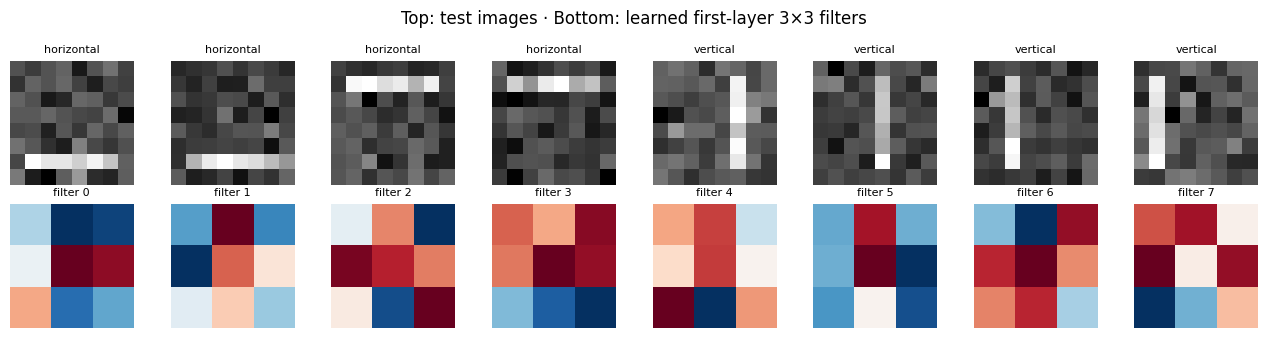

In [6]:
def bars(n, seed):
    r = np.random.default_rng(seed)
    X = r.normal(0, 0.3, size=(n, 8, 8, 1)); y = r.integers(0, 2, n)
    pos = r.integers(1, 7, n)
    for i in range(n):
        if y[i] == 0: X[i, pos[i], 1:7, 0] += 1.5
        else:         X[i, 1:7, pos[i], 0] += 1.5
    return X, y

Xb_tr, yb_tr = bars(400, 0); Xb_te, yb_te = bars(200, 1)
with timed("CNN on bars"):
    bar_net = CNNClassifier(input_shape=(8, 8, 1), num_classes=2, lr=0.01, epochs=10, batch_size=32, random_state=SEED, verbose=False).fit(Xb_tr, yb_tr)
checks.at_least("bars: test accuracy", bar_net.score(Xb_te, yb_te), 0.95)

fig, axes = plt.subplots(2, 8, figsize=(13, 3.4))
for i in range(4):
    axes[0, i].imshow(Xb_te[yb_te == 0][i, ..., 0], cmap="gray"); axes[0, i].set_title("horizontal", fontsize=8)
    axes[0, i + 4].imshow(Xb_te[yb_te == 1][i, ..., 0], cmap="gray"); axes[0, i + 4].set_title("vertical", fontsize=8)
for f in range(8):
    axes[1, f].imshow(bar_net.layers_[0].weight[f, 0], cmap="RdBu"); axes[1, f].set_title(f"filter {f}", fontsize=8)
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Top: test images · Bottom: learned first-layer 3×3 filters"); plt.tight_layout(); plt.show()

## 5. Real data: Digits (8 × 8 handwritten digits)

⏱️ CNN on Digits (15 epochs): 4.88s
Digits test accuracy: 0.9733 after 15 epochs
✅ Digits: test accuracy  (0.9733 ≥ 0.93)
✅ Digits: epoch loss decreased
✅ score() == accuracy of predict()  (max |Δ| = 0.00e+00)


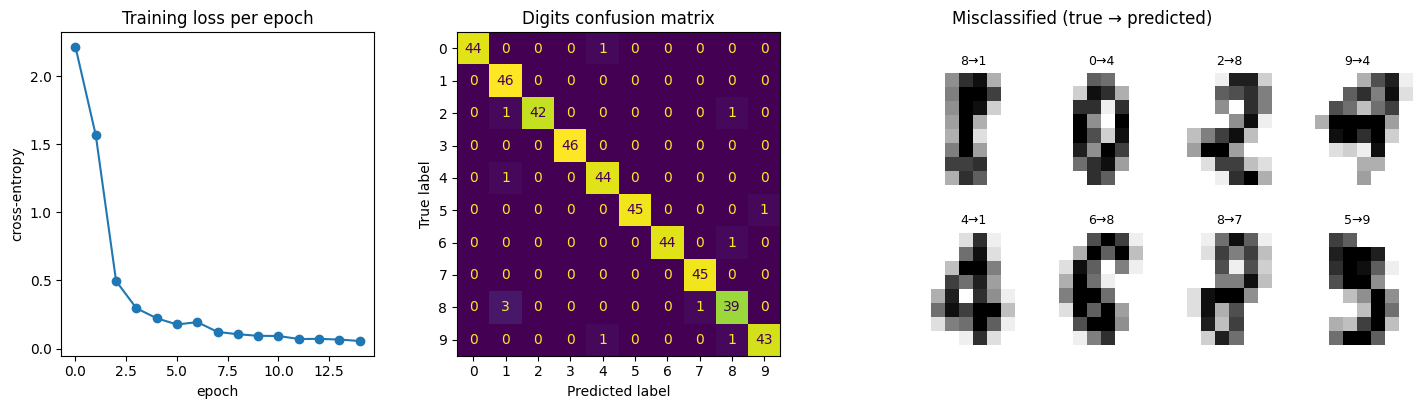

In [7]:
dig = datasets.load_digits()
X_dig = (dig.images / 16.0)[..., None]                       # scale pixels to [0, 1], add a channel axis
Xa, Xb, ya, yb = train_test_split(X_dig, dig.target, test_size=0.25, random_state=SEED, stratify=dig.target)
buf = io.StringIO()
with timed("CNN on Digits (15 epochs)"), contextlib.redirect_stdout(buf):
    dnet = CNNClassifier(input_shape=(8, 8, 1), num_classes=10, lr=0.01, epochs=15, batch_size=32, random_state=SEED, verbose=True).fit(Xa, ya)
epoch_losses = [float(l.split()[-1]) for l in buf.getvalue().splitlines() if l.startswith("Epoch")]
pred = dnet.predict(Xb)
acc_d = dnet.score(Xb, yb)
print(f"Digits test accuracy: {acc_d:.4f} after {len(epoch_losses)} epochs")
checks.at_least("Digits: test accuracy", acc_d, 0.93)
checks.check("Digits: epoch loss decreased", epoch_losses[-1] < 0.5 * epoch_losses[0])
checks.close("score() == accuracy of predict()", acc_d, skm.accuracy_score(yb, pred))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), gridspec_kw={"width_ratios": [1, 1.1, 1.4]})
ax[0].plot(epoch_losses, "o-"); ax[0].set(title="Training loss per epoch", xlabel="epoch", ylabel="cross-entropy")
skm.ConfusionMatrixDisplay.from_predictions(yb, pred, ax=ax[1], colorbar=False); ax[1].set_title("Digits confusion matrix")
wrong = np.flatnonzero(pred != yb)[:8]
ax[2].axis("off"); ax[2].set_title("Misclassified (true → predicted)")
for k, i in enumerate(wrong):
    sub = fig.add_axes([0.66 + (k % 4) * 0.08, 0.5 - (k // 4) * 0.38, 0.07, 0.3])
    sub.imshow(Xb[i, ..., 0], cmap="gray_r"); sub.set_title(f"{yb[i]}→{pred[i]}", fontsize=9); sub.axis("off")
plt.show()

## 6. Training options

In [8]:
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    CNNClassifier(input_shape=(8, 8, 1), num_classes=10, epochs=200, lr=0.01, random_state=0, verbose=True,
                  early_stopping=True, n_iter_no_change=2, tol=0.05).fit(Xa[:300], ya[:300])
log = buf.getvalue()
n_epochs = sum(l.startswith("Epoch") for l in log.splitlines())
checks.check("early stopping halts before max epochs", "Early stopping" in log and n_epochs < 200, f"stopped after {n_epochs} epochs")

buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    CNNClassifier(input_shape=(8, 8, 1), num_classes=10, epochs=2, verbose=False).fit(Xa[:64], ya[:64])
checks.check("verbose=False prints nothing", buf.getvalue() == "")

def short_run(**kw):
    m = CNNClassifier(input_shape=(8, 8, 1), num_classes=10, epochs=4, random_state=0, verbose=False, early_stopping=False, **kw)
    return m.fit(Xa, ya).score(Xb, yb)

acc_mom, acc_plain = short_run(momentum=0.9), short_run(momentum=0.0)
print(f"4 epochs: momentum 0.9 → {acc_mom:.3f} | no momentum → {acc_plain:.3f}")
checks.check("momentum speeds up training (4 epochs)", acc_mom > acc_plain, f"{acc_mom:.3f} vs {acc_plain:.3f}")
checks.at_least("max_grad_norm clipping still trains", short_run(max_grad_norm=1.0), 0.8)
checks.at_least("lr_decay still trains", short_run(lr_decay=0.1), 0.8)
checks.at_least("L2 alpha still trains", short_run(alpha=1e-4), 0.8)

✅ early stopping halts before max epochs  (stopped after 19 epochs)
✅ verbose=False prints nothing


4 epochs: momentum 0.9 → 0.900 | no momentum → 0.438
✅ momentum speeds up training (4 epochs)  (0.900 vs 0.438)


✅ max_grad_norm clipping still trains  (0.8911 ≥ 0.8)


✅ lr_decay still trains  (0.9000 ≥ 0.8)


✅ L2 alpha still trains  (0.9000 ≥ 0.8)


True

## 7. Real data (online): MNIST

We train on 3 000 of the 60 000 MNIST training images for 3 epochs and test on 2 000 held-out images. Even this small pure-NumPy CNN should exceed 85 %.

🌐 MNIST (OpenML): downloaded / loaded from cache


Epoch 0 Loss 1.2902


Epoch 1 Loss 0.3326


Epoch 2 Loss 0.2508
⏱️ CNN on 3 000 MNIST images (3 epochs): 16.66s


MNIST test accuracy: 0.9175
✅ MNIST: test accuracy  (0.9175 ≥ 0.85)


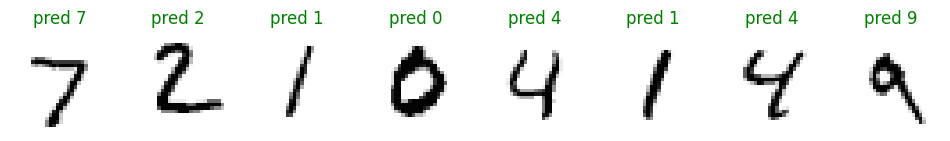

In [9]:
def _mnist():
    from sklearn.datasets import fetch_openml
    m = fetch_openml("mnist_784", version=1, as_frame=False, parser="liac-arff")
    return (m.data / 255.0).reshape(-1, 28, 28, 1), m.target.astype(int)

mnist, online = load_online("MNIST (OpenML)", _mnist)
if online:
    Xm, ym = mnist
    Xm_tr, ym_tr, Xm_te, ym_te = Xm[:3000], ym[:3000], Xm[60000:62000], ym[60000:62000]
    with timed("CNN on 3 000 MNIST images (3 epochs)"):
        mnet = CNNClassifier(input_shape=(28, 28, 1), num_classes=10, epochs=3, batch_size=32, random_state=SEED, verbose=True).fit(Xm_tr, ym_tr)
    acc_m = mnet.score(Xm_te, ym_te)
    print(f"MNIST test accuracy: {acc_m:.4f}")
    checks.at_least("MNIST: test accuracy", acc_m, 0.85)
    fig, axes = plt.subplots(1, 8, figsize=(12, 1.9))
    pm = mnet.predict(Xm_te[:8])
    for i, ax in enumerate(axes):
        ax.imshow(Xm_te[i, ..., 0], cmap="gray_r"); ax.set_title(f"pred {pm[i]}", color="g" if pm[i] == ym_te[i] else "r"); ax.axis("off")
    plt.show()
else:
    checks.skip("MNIST checks", "dataset unavailable offline")

## 8. API contract and input validation

In [10]:
m = CNNClassifier(input_shape=(8, 8, 1), num_classes=10, epochs=1, verbose=False, random_state=0)
checks.check("fit() returns self", m.fit(Xa[:64], ya[:64]) is m)
checks.check("3-D input accepted for single-channel images", m.predict(Xb[:5, ..., 0]).shape == (5,))
a = CNNClassifier(input_shape=(8, 8, 1), epochs=2, verbose=False, random_state=5).fit(Xa[:200], ya[:200]).predict(Xb)
b = CNNClassifier(input_shape=(8, 8, 1), epochs=2, verbose=False, random_state=5).fit(Xa[:200], ya[:200]).predict(Xb)
checks.check("same random_state → identical predictions", np.array_equal(a, b))
checks.check("default architecture: conv-relu-pool-conv-relu for 8×8", [type(l).__name__ for l in m.layers_] ==
             ["ConvLayer", "ReLULayer", "PoolingLayer", "ConvLayer", "ReLULayer"])
checks.raises("predict before fit raises RuntimeError", RuntimeError, lambda: CNNClassifier().predict(Xb))
checks.raises("wrong image size raises", ValueError, lambda: CNNClassifier(input_shape=(28, 28, 1), verbose=False).fit(Xa[:10], ya[:10]))
checks.raises("negative labels raise", ValueError, lambda: CNNClassifier(input_shape=(8, 8, 1), verbose=False).fit(Xa[:4], np.array([0, 1, -1, 2])))
checks.raises("non-integer labels raise", ValueError, lambda: CNNClassifier(input_shape=(8, 8, 1), verbose=False).fit(Xa[:2], np.array([0.5, 1.0])))
checks.raises("NaN pixels raise", ValueError, lambda: CNNClassifier(input_shape=(8, 8, 1), verbose=False).fit(np.full((2, 8, 8, 1), np.nan), np.array([0, 1])))
checks.raises("lr ≤ 0 raises", ValueError, lambda: CNNClassifier(lr=0))
checks.raises("momentum ≥ 1 raises", ValueError, lambda: CNNClassifier(momentum=1.0))

✅ fit() returns self
✅ 3-D input accepted for single-channel images


✅ same random_state → identical predictions
✅ default architecture: conv-relu-pool-conv-relu for 8×8
✅ predict before fit raises RuntimeError  (RuntimeError: this CNNClassifier is not fitted yet; call fit() first)
✅ wrong image size raises  (ValueError: input shape (8, 8, 1) does not match input_shape=(28, 28, 1))
✅ negative labels raise  (ValueError: class labels must be non-negative integers)
✅ non-integer labels raise  (ValueError: y must contain integer class labels)
✅ NaN pixels raise  (ValueError: X contains NaN or infinite values)
✅ lr ≤ 0 raises  (ValueError: lr must be positive, got 0)
✅ momentum ≥ 1 raises  (ValueError: momentum must be in [0, 1), got 1.0)


True

## Summary

In [11]:
checks.summary()

09 cnn: 58 passed, 0 failed, 0 skipped, 0 known bug(s) (58 checks)


,check,status,detail
0,"get_patches shape (B, out_h, out_w, C, kh, kw)",pass,
1,"patch [b=1, i=1, j=4] equals the manual slice",pass,max |Δ| = 0.00e+00
2,get_patches returns a view (no copy),pass,
3,pad_images(int) adds the border on every side,pass,
4,padding is zeros and the centre is untouched,pass,
5,"pad_images(((1, 0), (0, 2))) pads asymmetrically",pass,
6,conv k=3 stride=1 pad=0 == naive loop,pass,max |Δ| = 8.88e-16
7,"get_output_shape matches (k=3, s=1, p=0)",pass,
8,conv k=3 stride=2 pad=1 == naive loop,pass,max |Δ| = 4.44e-16
9,"get_output_shape matches (k=3, s=2, p=1)",pass,
